📧 — Spam Email Detector

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
# Sample email dataset
emails = [
    # Spam emails
    ("Win a free iPhone now! Click here to claim your prize!", 1),
    ("Congratulations! You have won $1,000,000. Call now!", 1),
    ("FREE offer! Buy one get one free. Limited time only!", 1),
    ("Urgent! Your account will be suspended. Verify now!", 1),
    ("Make money fast! Work from home earn $500 daily!", 1),
    ("Click here to claim your free gift card now!", 1),
    ("You are selected for a special prize. Reply immediately!", 1),
    ("Cheap loans available! No credit check required!", 1),
    ("Hot singles in your area! Click to meet them now!", 1),
    ("Warning! Virus detected on your computer. Fix now free!", 1),
    ("Double your income! Guaranteed investment returns!", 1),
    ("Free vacation package! You have been selected!", 1),
    ("Lose weight fast with this miracle pill!", 1),
    ("Your PayPal account needs verification. Click here!", 1),
    ("Buy cheap medicines online. No prescription needed!", 1),

    # Normal emails
    ("Hi, can we schedule a meeting for tomorrow afternoon?", 0),
    ("Please find the attached project report for your review.", 0),
    ("The team lunch is scheduled for Friday at 1pm.", 0),
    ("Your order has been shipped and will arrive by Monday.", 0),
    ("Reminder: Please submit your assignment before deadline.", 0),
    ("Thank you for attending the workshop yesterday.", 0),
    ("Can you please review the document I sent earlier?", 0),
    ("Happy birthday! Hope you have a wonderful day.", 0),
    ("The meeting has been rescheduled to 3pm on Wednesday.", 0),
    ("Please confirm your attendance for the conference.", 0),
    ("Your flight booking confirmation number is ABC123.", 0),
    ("I wanted to follow up on our discussion last week.", 0),
    ("The quarterly report is ready for your review.", 0),
    ("Let me know if you need any help with the project.", 0),
    ("Looking forward to working with you on this project.", 0),
]

df = pd.DataFrame(emails, columns=["text", "label"])
print("Dataset shape:", df.shape)
print(f"\nSpam emails  : {df['label'].sum()}")
print(f"Normal emails: {(df['label']==0).sum()}")
print(df.head())

Dataset shape: (30, 2)

Spam emails  : 15
Normal emails: 15
                                                text  label
0  Win a free iPhone now! Click here to claim you...      1
1  Congratulations! You have won $1,000,000. Call...      1
2  FREE offer! Buy one get one free. Limited time...      1
3  Urgent! Your account will be suspended. Verify...      1
4   Make money fast! Work from home earn $500 daily!      1


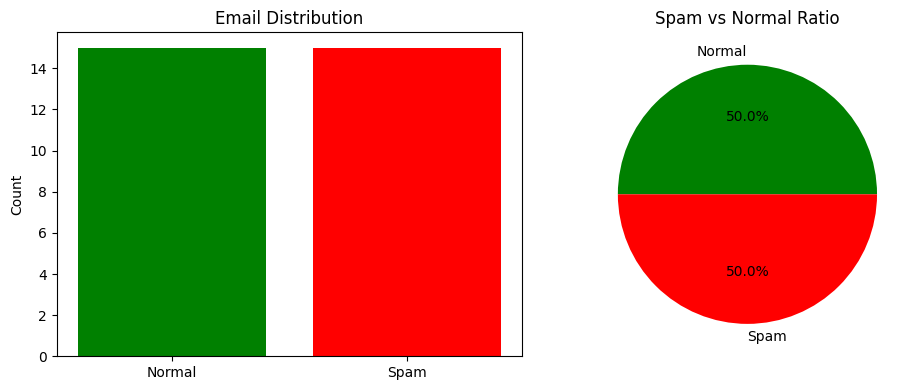

In [9]:
# Plot spam vs normal
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
counts = df["label"].value_counts()
plt.bar(["Normal", "Spam"], counts.values, color=["green", "red"])
plt.title("Email Distribution")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.pie(counts.values,
        labels=["Normal", "Spam"],
        colors=["green", "red"],
        autopct="%1.1f%%")
plt.title("Spam vs Normal Ratio")

plt.tight_layout()
plt.show()

In [10]:
# Prepare features
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["text"])
y = df["label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


=== Model Performance ===
Accuracy: 100.0%

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         4
        Spam       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



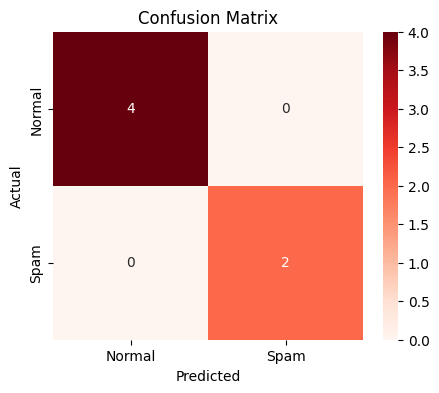

In [11]:
# Predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"=== Model Performance ===")
print(f"Accuracy: {accuracy * 100:.1f}%")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=["Normal", "Spam"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Reds",
            xticklabels=["Normal", "Spam"],
            yticklabels=["Normal", "Spam"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [12]:
def predict_email(email_text):
    input_data = vectorizer.transform([email_text])
    result = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0]

    print("=== Spam Email Detector ===")
    print(f"Email: {email_text[:60]}...")
    print(f"Spam Probability : {probability[1]*100:.1f}%")
    print(f"Result : {'🚨 SPAM' if result == 1 else '✅ NORMAL'}")
    print()

# Test your own emails
predict_email("Congratulations! You won a free iPhone. Click now!")
predict_email("Hi, please review the attached report before Friday.")
predict_email("Make money fast! Earn $500 daily working from home!")
predict_email("The team meeting is scheduled for tomorrow at 2pm.")

=== Spam Email Detector ===
Email: Congratulations! You won a free iPhone. Click now!...
Spam Probability : 99.8%
Result : 🚨 SPAM

=== Spam Email Detector ===
Email: Hi, please review the attached report before Friday....
Spam Probability : 0.1%
Result : ✅ NORMAL

=== Spam Email Detector ===
Email: Make money fast! Earn $500 daily working from home!...
Spam Probability : 99.3%
Result : 🚨 SPAM

=== Spam Email Detector ===
Email: The team meeting is scheduled for tomorrow at 2pm....
Spam Probability : 3.3%
Result : ✅ NORMAL

